In [ ]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt

from genflows.utils.plotting_lobes import custom_cmap, draw_mask_boundary, find_transition_slices, plot_inpaint_comparison

# Training Progress & Multi-Epoch Comparison

This notebook monitors iterative training of the Flow Matching inpainting model.
- **Loss curve**: should decrease smoothly across training segments
- **Visual quality**: generated lobes should look geological, not noisy
- **Boundary continuity**: smooth transitions at mask edges, no discontinuities
- **NTG accuracy**: net-to-gross of generated samples should approach ground truth

## Optional: Run Sampling
Skip this cell to plot from existing .npy files. Run it to generate fresh samples.

In [ ]:
# --- Set SAMPLE = True to generate fresh samples, False to skip ---
SAMPLE = False
SAMPLE_EPOCH = None  # None = latest checkpoint

if SAMPLE:
    import subprocess, sys
    cmd = [sys.executable, 'sample.py']
    if SAMPLE_EPOCH is not None:
        cmd += ['--epoch', str(SAMPLE_EPOCH)]
    print(f"Running: {' '.join(cmd)}")
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print(f"ERROR:\n{result.stderr}")
else:
    print("Skipping sampling — plotting from existing .npy files.")

In [ ]:
# --- Loss Curve ---
loss_path = 'checkpoints/loss_history.npy'
if os.path.exists(loss_path):
    losses = np.load(loss_path)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(range(1, len(losses) + 1), losses, 'b-', linewidth=1)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Training Loss')
    ax.set_title('Flow Matching Inpaint — Training Loss')
    ax.grid(True, alpha=0.3)
    # Mark segment boundaries (every 25 epochs)
    for e in range(25, len(losses) + 1, 25):
        ax.axvline(e, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)
        ax.text(e, ax.get_ylim()[1], f'  {e}', fontsize=8, va='top', color='gray')
    plt.tight_layout()
    plt.show()
    print(f"Total epochs trained: {len(losses)}")
    print(f"Latest loss: {losses[-1]:.4f}")
    if len(losses) > 25:
        print(f"Loss at epoch 25: {losses[24]:.4f}")
else:
    print("No loss history found. Run train.py first.")

## Epoch Comparison
Compare inpainting quality across training epochs for the same mask/sample.

In [ ]:
# Discover all epoch result directories
epoch_dirs = sorted(glob.glob('results/epoch_*'))
available_epochs = []
for d in epoch_dirs:
    m = re.search(r'epoch_(\d+)', d)
    if m:
        available_epochs.append(int(m.group(1)))
print(f"Available epochs: {available_epochs}")

if len(available_epochs) >= 2:
    # Compare 'boundaries' scenario, sample 0, XY mid-slice across epochs
    scenario = 'boundaries'
    sample_idx = 0

    n_epochs = len(available_epochs)
    fig, axes = plt.subplots(2, n_epochs + 1, figsize=(4 * (n_epochs + 1), 8))
    fig.suptitle(f'{scenario.title()} — Sample {sample_idx} across epochs', fontsize=14, fontweight='bold')

    # Load ground truth from first epoch dir
    gt = np.load(os.path.join(epoch_dirs[0], 'ground_truth.npy'))
    mask = np.load(os.path.join(epoch_dirs[0], f'mask_{scenario}.npy'))
    z_mid = 25  # mid-slice

    # First column: ground truth
    axes[0, 0].imshow(gt[sample_idx, 0, :, :, z_mid].T, cmap=custom_cmap, vmin=0, vmax=1, origin='lower')
    axes[0, 0].set_title('Ground Truth')
    axes[1, 0].imshow(mask[sample_idx, 0, :, :, z_mid].T, cmap='gray', vmin=0, vmax=1, origin='lower')
    axes[1, 0].set_title('Mask')

    for col, epoch in enumerate(available_epochs, 1):
        epoch_dir = f'results/epoch_{epoch:03d}'
        res = np.load(os.path.join(epoch_dir, f'flow_matching_{scenario}_50steps.npy'))
        m = np.load(os.path.join(epoch_dir, f'mask_{scenario}.npy'))

        # XY slice
        axes[0, col].imshow(res[sample_idx, 0, :, :, z_mid].T, cmap=custom_cmap, vmin=0, vmax=1, origin='lower')
        axes[0, col].set_title(f'Epoch {epoch}')

        # XZ slice
        axes[1, col].imshow(res[sample_idx, 0, :, 25, :].T, cmap=custom_cmap, vmin=0, vmax=1, origin='lower')
        # Overlay pixel-aligned mask boundary
        m_slice = m[sample_idx, 0, :, 25, :].T
        draw_mask_boundary(axes[1, col], m_slice, color='red', linewidth=1)
        axes[1, col].set_title(f'Epoch {epoch} (XZ)')

    plt.tight_layout()
    plt.show()
elif len(available_epochs) == 1:
    print(f"Only one epoch available ({available_epochs[0]}). Train more segments to compare.")
else:
    print("No epoch results found. Run sample.py after training.")

## Metrics Progression
NTG and match rate across epochs — should improve with training.

In [ ]:
# Metrics progression across epochs
mask_names = ['wells', 'boundaries', 'cross_section', 'combo_wells_bounds', 'combo_all']

if available_epochs:
    print(f"{'Epoch':<8}", end='')
    for name in mask_names:
        print(f"{'NTG ' + name:<20}", end='')
    print(f"{'GT NTG':<10}")
    print("-" * (8 + 20 * len(mask_names) + 10))

    for epoch in available_epochs:
        epoch_dir = f'results/epoch_{epoch:03d}'
        gt_e = np.load(os.path.join(epoch_dir, 'ground_truth.npy'))
        gt_ntg = gt_e.mean()
        print(f"{epoch:<8}", end='')
        for name in mask_names:
            res_path = os.path.join(epoch_dir, f'flow_matching_{name}_50steps.npy')
            if os.path.exists(res_path):
                res = np.load(res_path)
                print(f"{res.mean():<20.3f}", end='')
            else:
                print(f"{'N/A':<20}", end='')
        print(f"{gt_ntg:<10.3f}")

    # Plot NTG convergence
    if len(available_epochs) >= 2:
        fig, ax = plt.subplots(figsize=(10, 4))
        for name in mask_names:
            ntgs = []
            for epoch in available_epochs:
                res_path = f'results/epoch_{epoch:03d}/flow_matching_{name}_50steps.npy'
                if os.path.exists(res_path):
                    ntgs.append(np.load(res_path).mean())
                else:
                    ntgs.append(np.nan)
            ax.plot(available_epochs, ntgs, 'o-', label=name)
        ax.axhline(gt_ntg, color='black', linestyle='--', label=f'GT NTG ({gt_ntg:.3f})')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('NTG')
        ax.set_title('NTG Convergence Across Training')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("No epoch results found.")

In [ ]:
# Load results from .npy files (no need to re-run sample.py)
# Change EPOCH to view a specific checkpoint, or leave None for latest
EPOCH = available_epochs[-1] if available_epochs else None
results_dir = f'results/epoch_{EPOCH:03d}' if EPOCH else 'results'

print(f"Loading results from: {results_dir}")
gt = np.load(os.path.join(results_dir, 'ground_truth.npy'))          # (4, 1, 50, 50, 50)
gt_cond = np.load(os.path.join(results_dir, 'ground_truth_cond.npy')) # (4, 5)

mask_names = ['wells', 'boundaries', 'cross_section', 'combo_wells_bounds', 'combo_all']
masks = {name: np.load(os.path.join(results_dir, f'mask_{name}.npy')) for name in mask_names}
results = {name: np.load(os.path.join(results_dir, f'flow_matching_{name}_50steps.npy')) for name in mask_names}

n_samples = gt.shape[0]
print(f"Epoch: {EPOCH}, Ground truth: {gt.shape}, samples per scenario: {n_samples}")
for name in mask_names:
    known_frac = masks[name].mean()
    print(f"  {name}: mask known={known_frac:.1%}, result shape={results[name].shape}")

## Detailed Per-Scenario Plots (Latest Epoch)

Plotting functions (`plot_inpaint_comparison`, `draw_mask_boundary`, `find_transition_slices`) are defined in `plotting.py` and imported above.

### Wells
Well masks: 1-5 vertical or L-shaped wells, 1 voxel wide, variable depth.

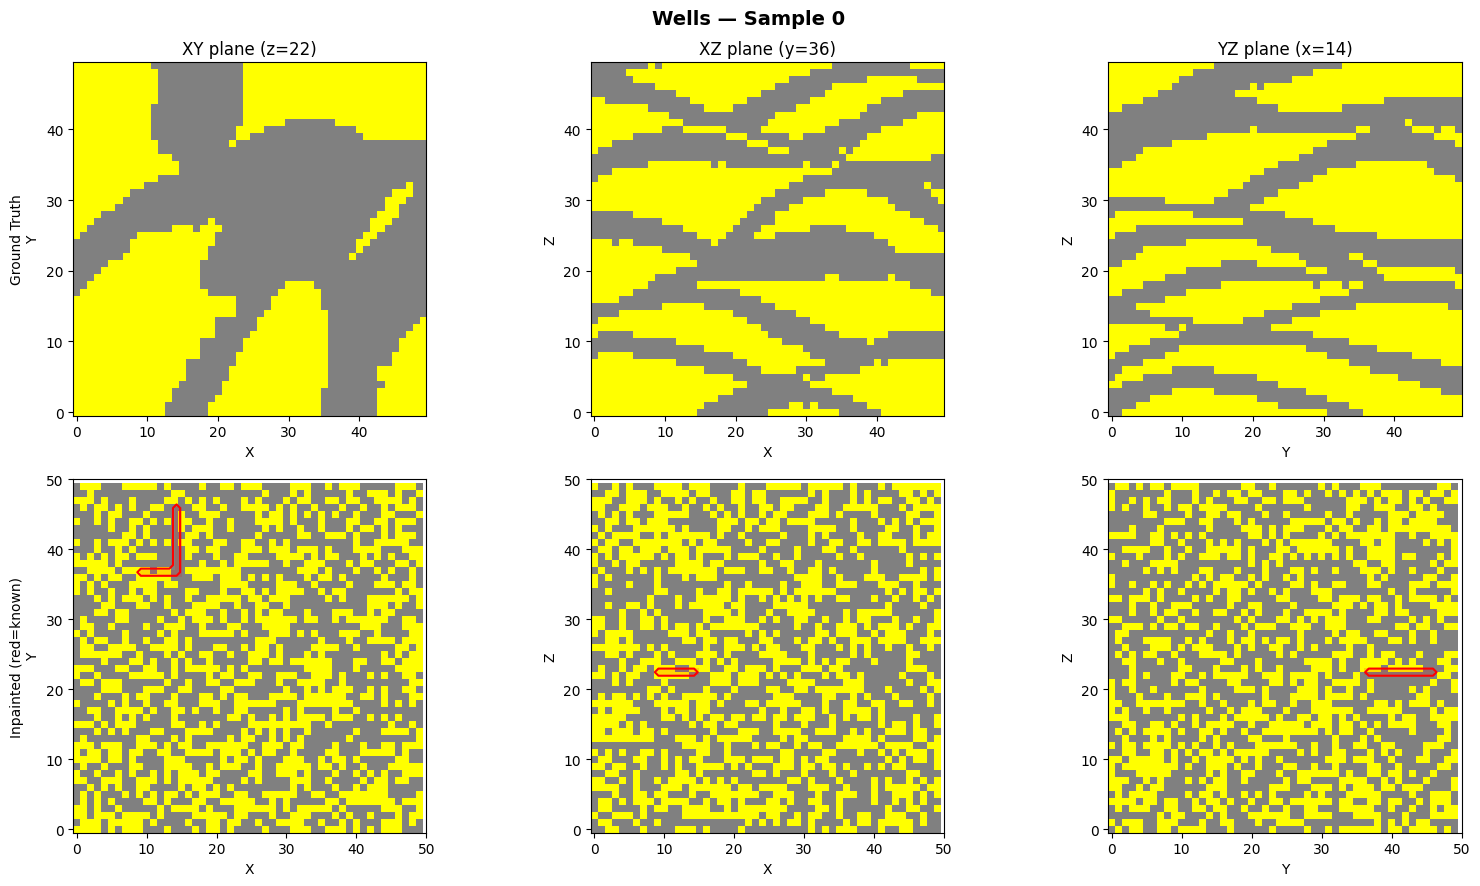

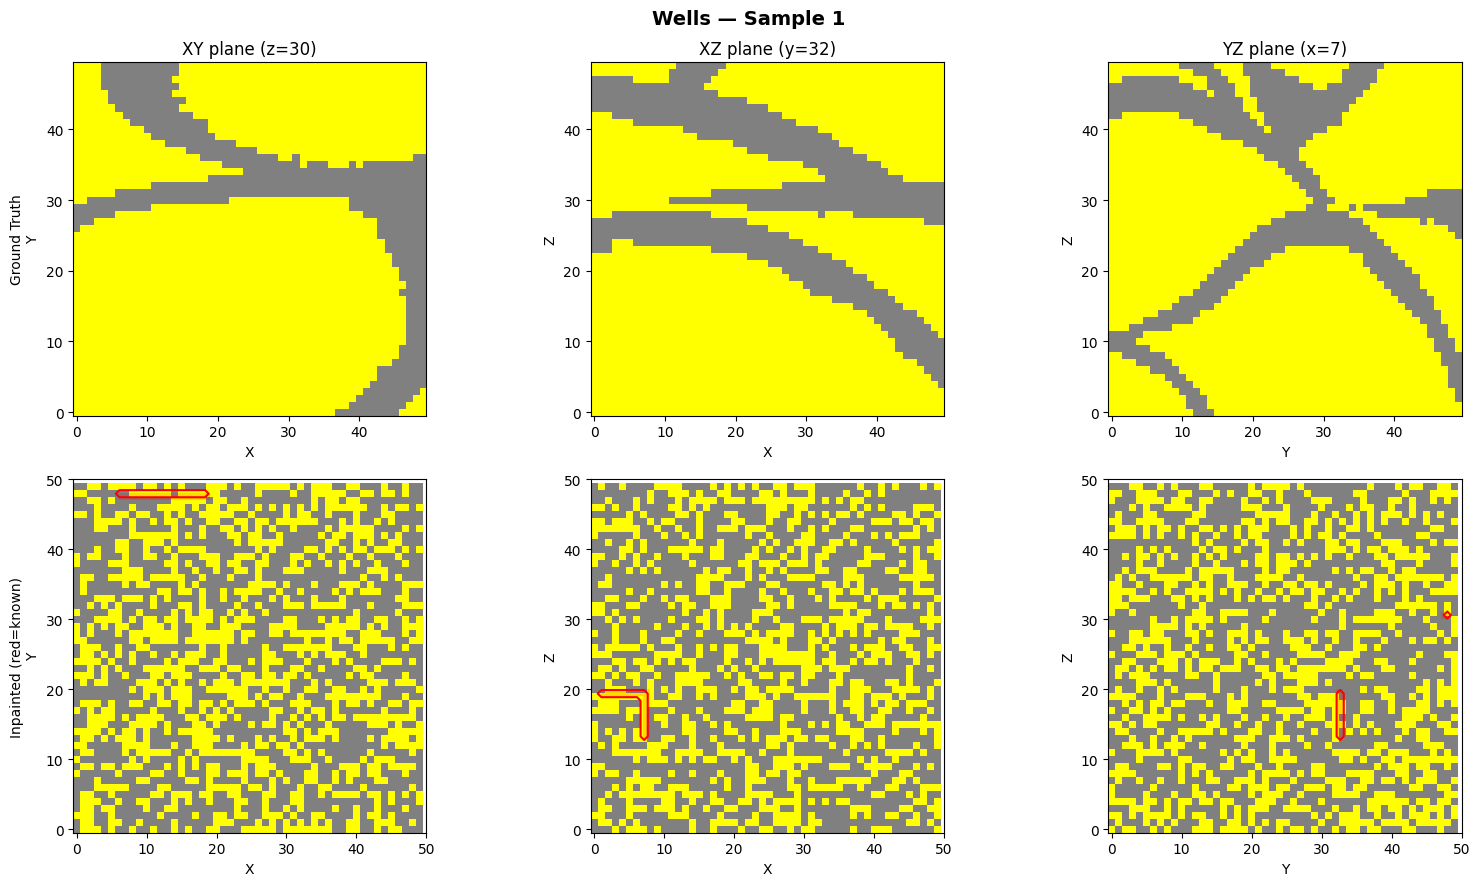

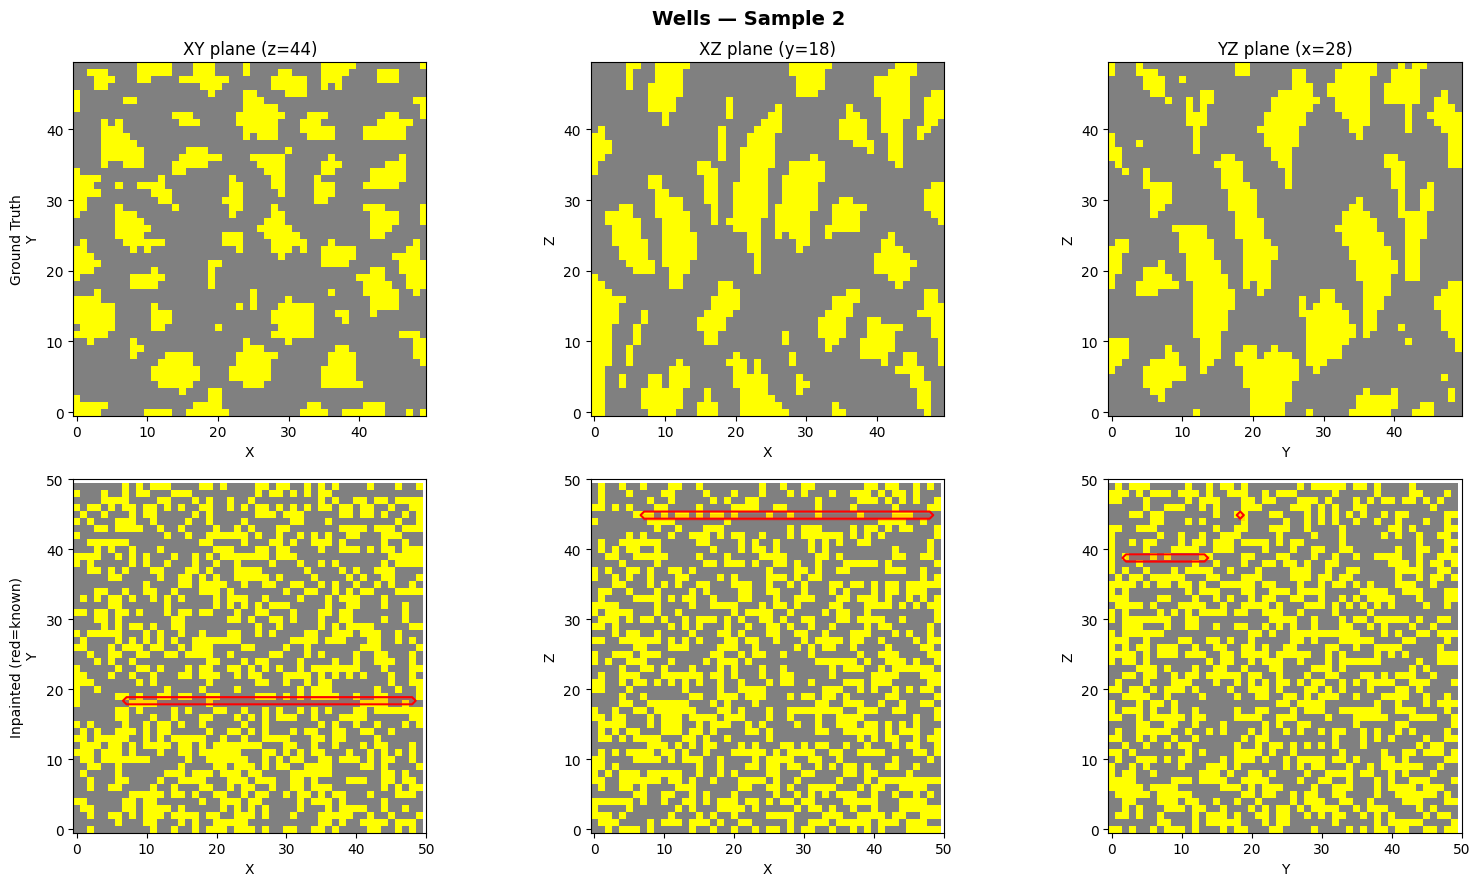

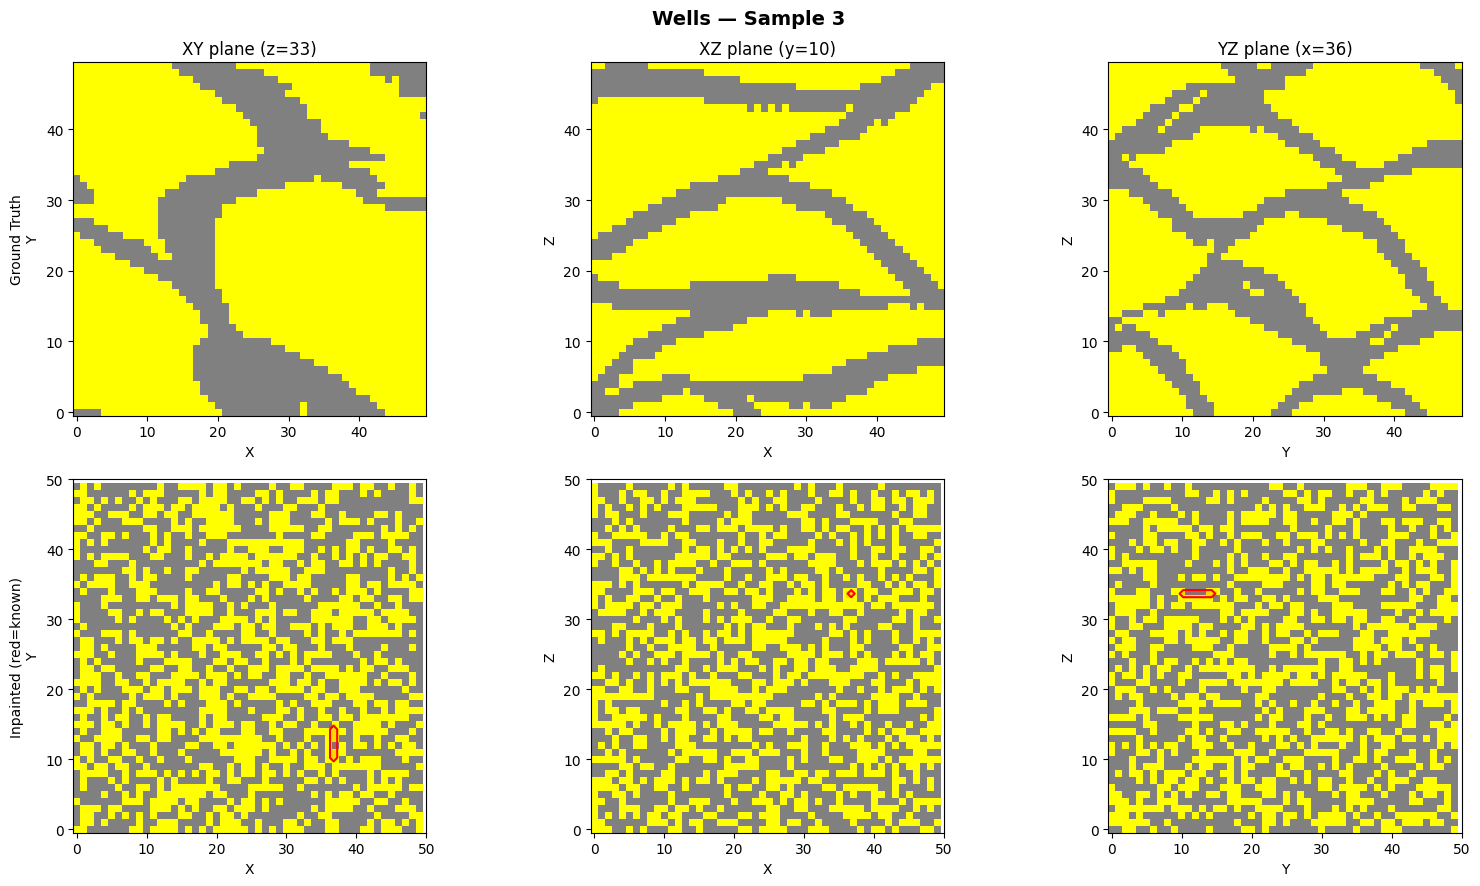

In [4]:
for i in range(n_samples):
    plot_inpaint_comparison(
        gt[i, 0], results['wells'][i, 0], masks['wells'][i, 0],
        f'Wells — Sample {i}'
    )

## Boundaries
Boundary masks: 1-6 faces of the 50x50x50 cube, 1-3 voxels thick. For autoregressive reservoir generation.

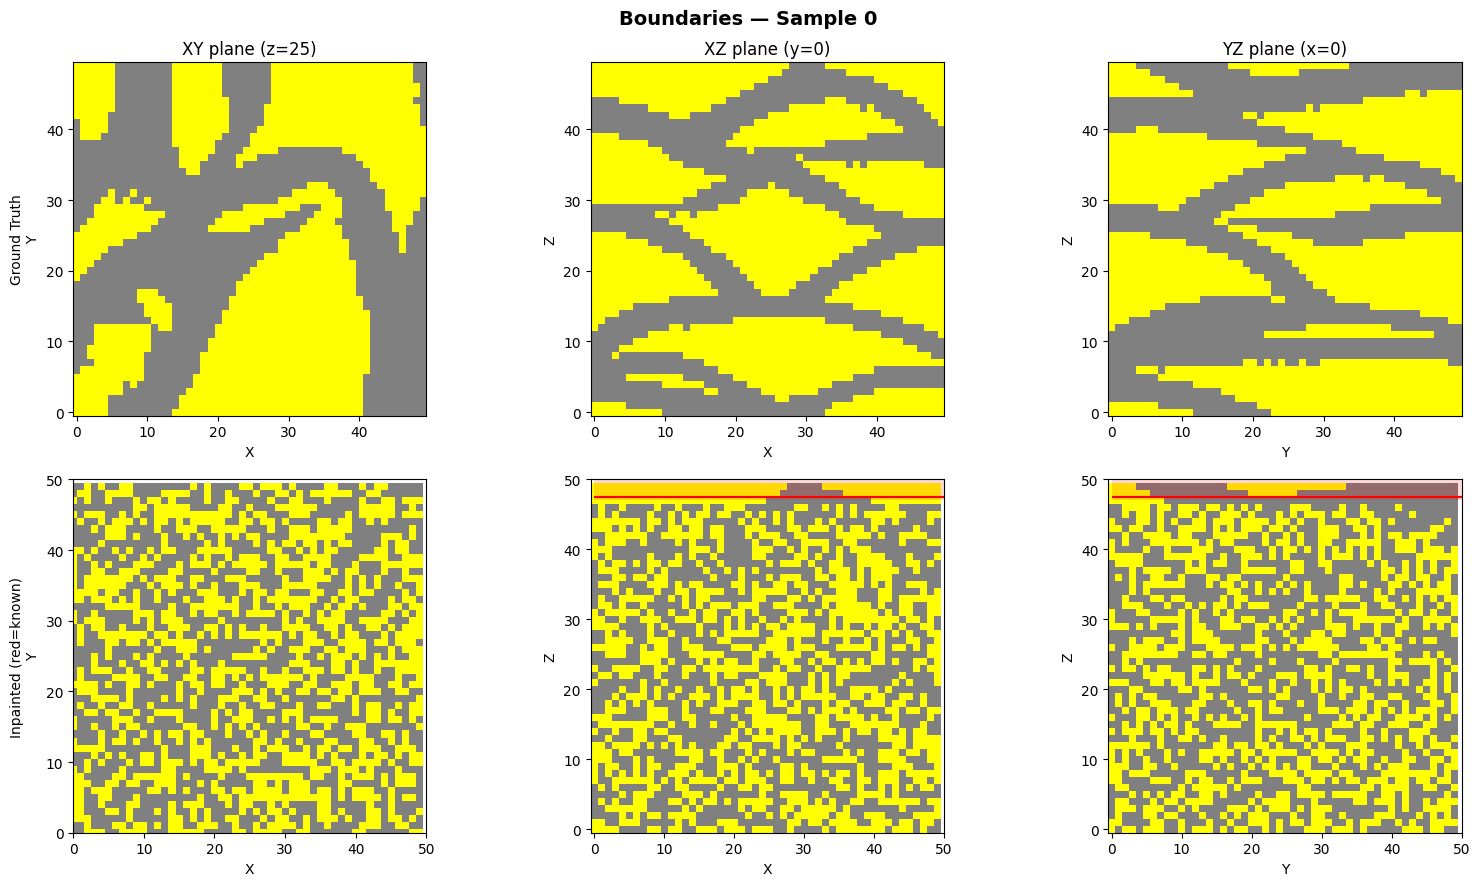

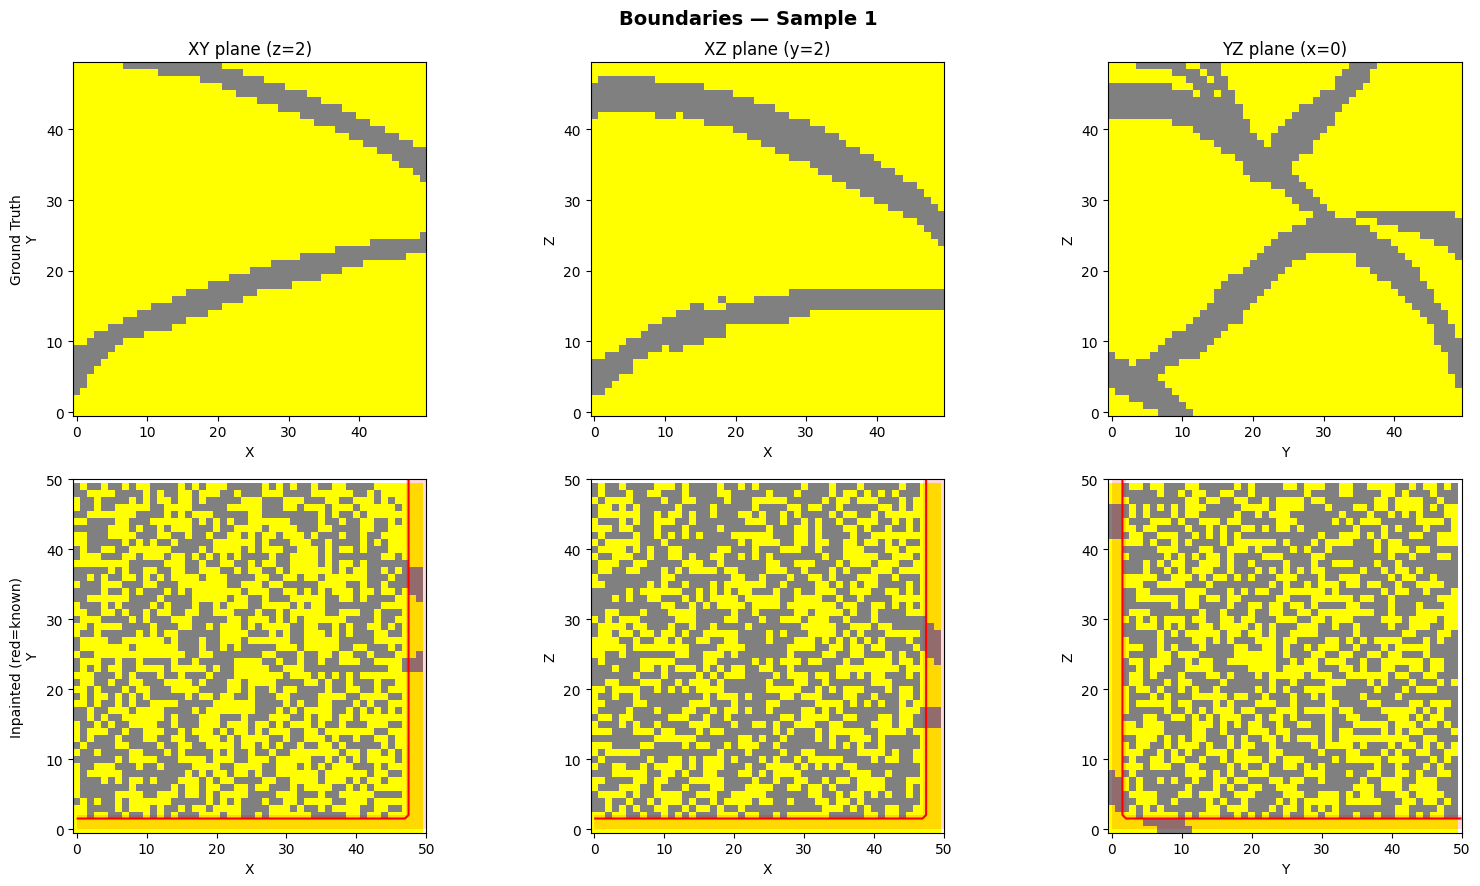

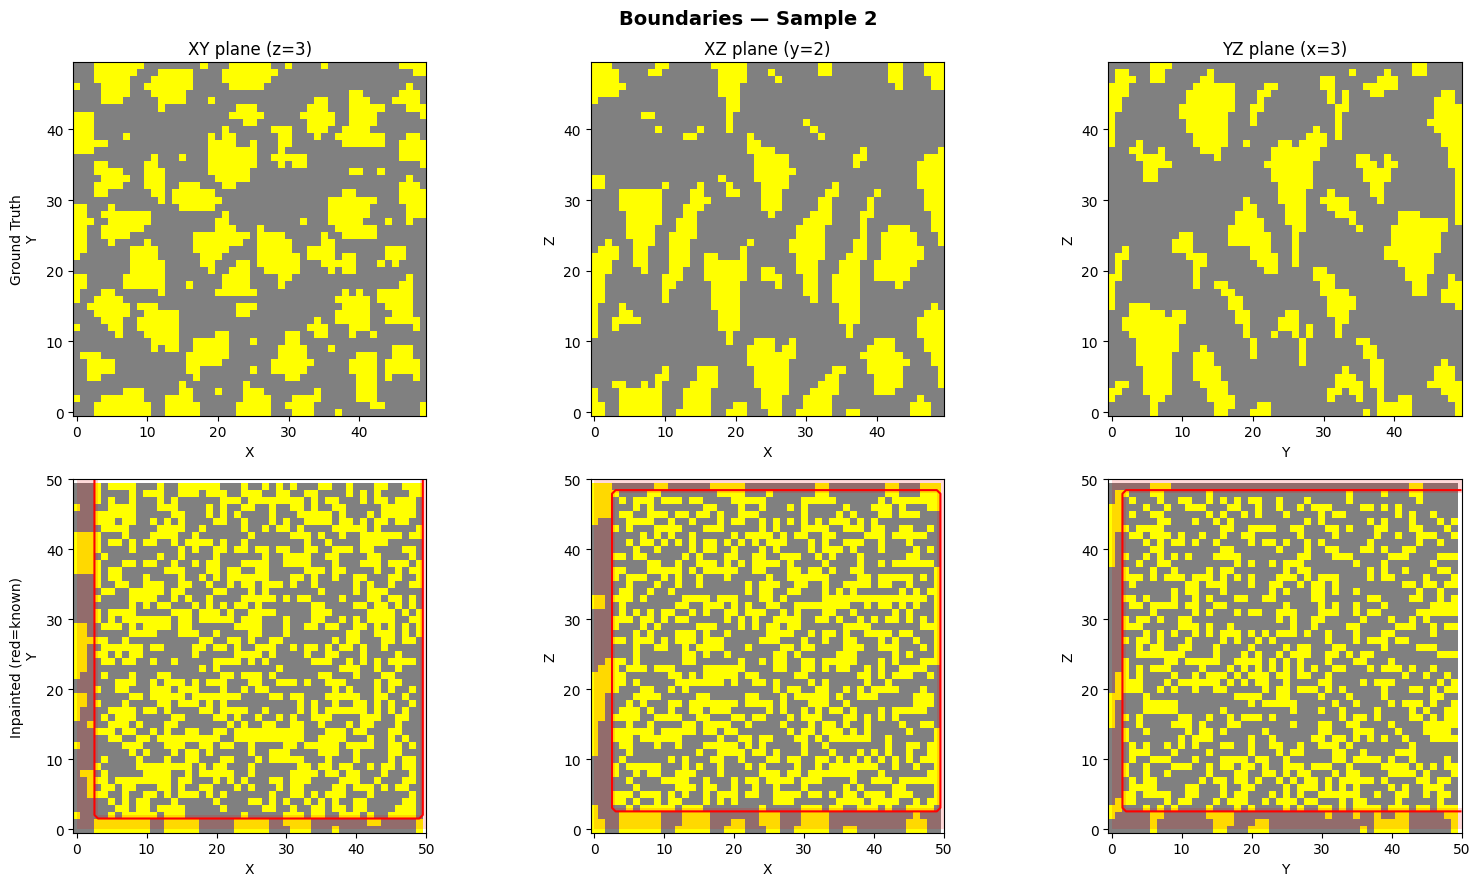

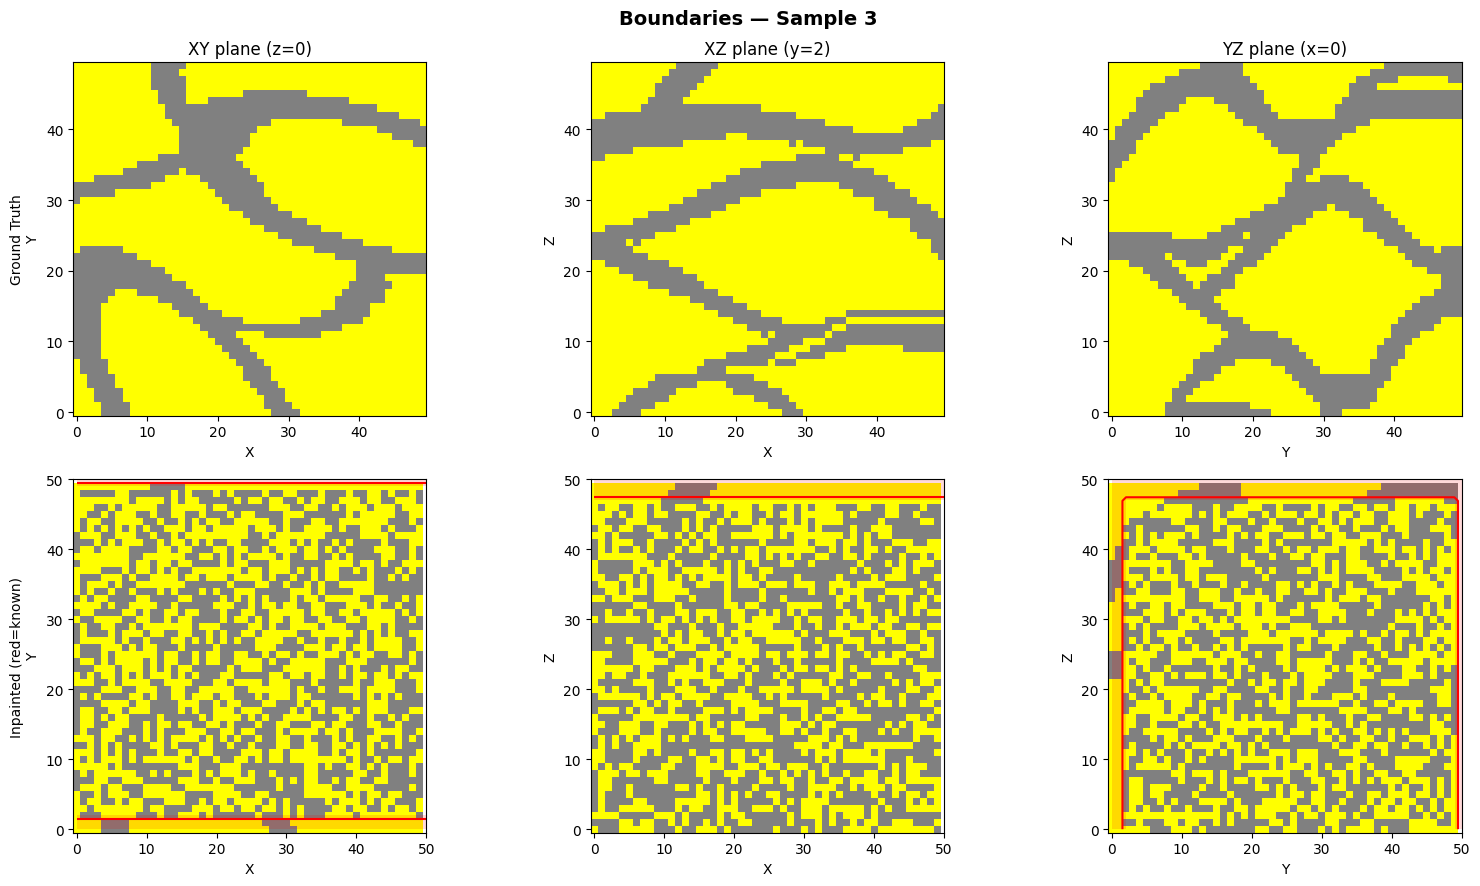

In [5]:
for i in range(n_samples):
    plot_inpaint_comparison(
        gt[i, 0], results['boundaries'][i, 0], masks['boundaries'][i, 0],
        f'Boundaries — Sample {i}'
    )

## Cross-Sections
2D cross-section masks: 1 voxel thick plane at any angle in x-y, up to 30 deg z-tilt. For seismic conditioning.

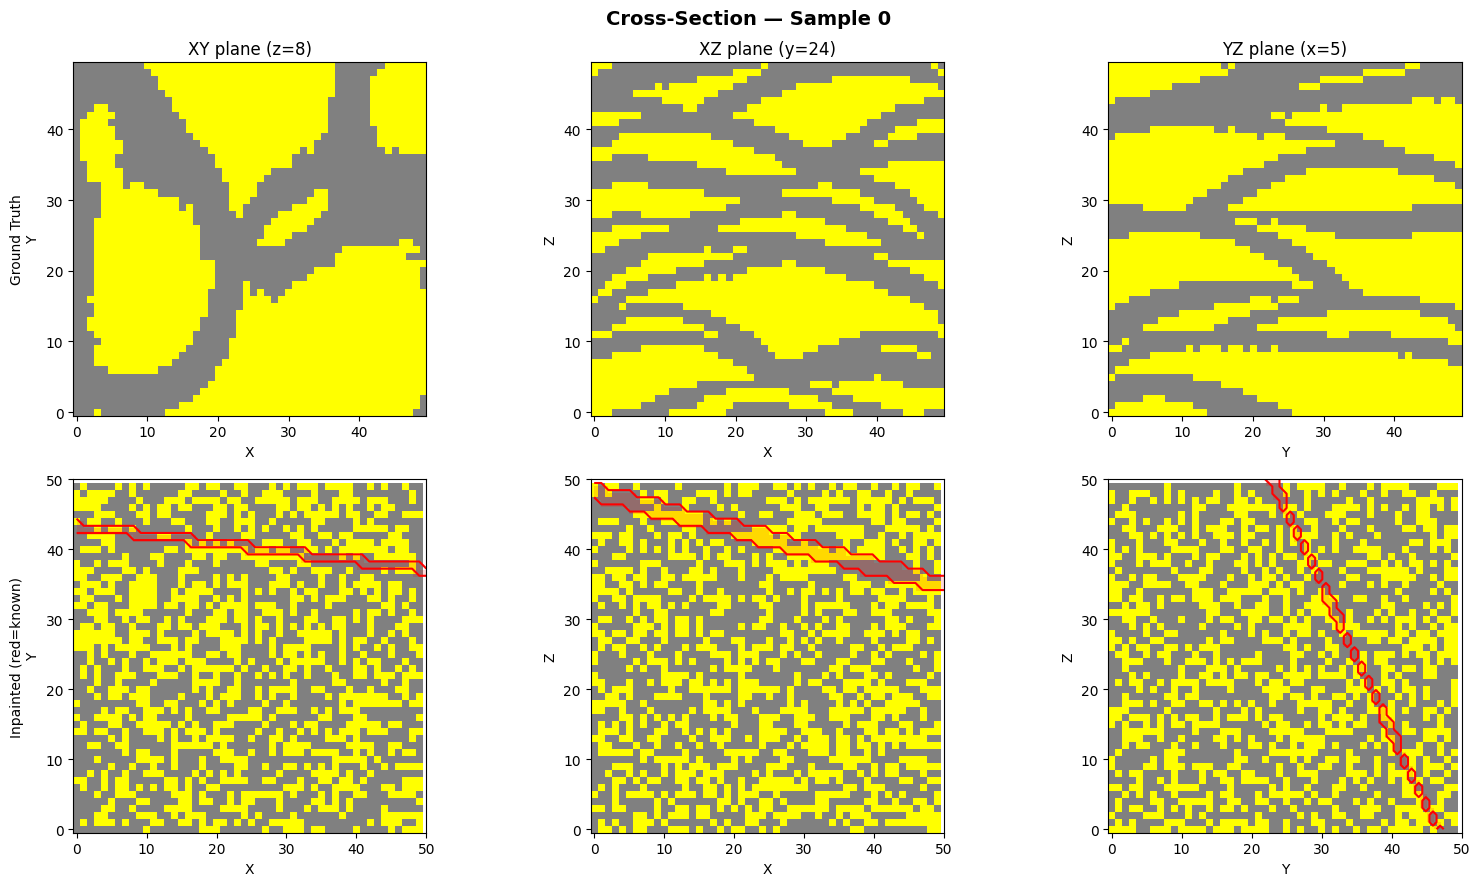

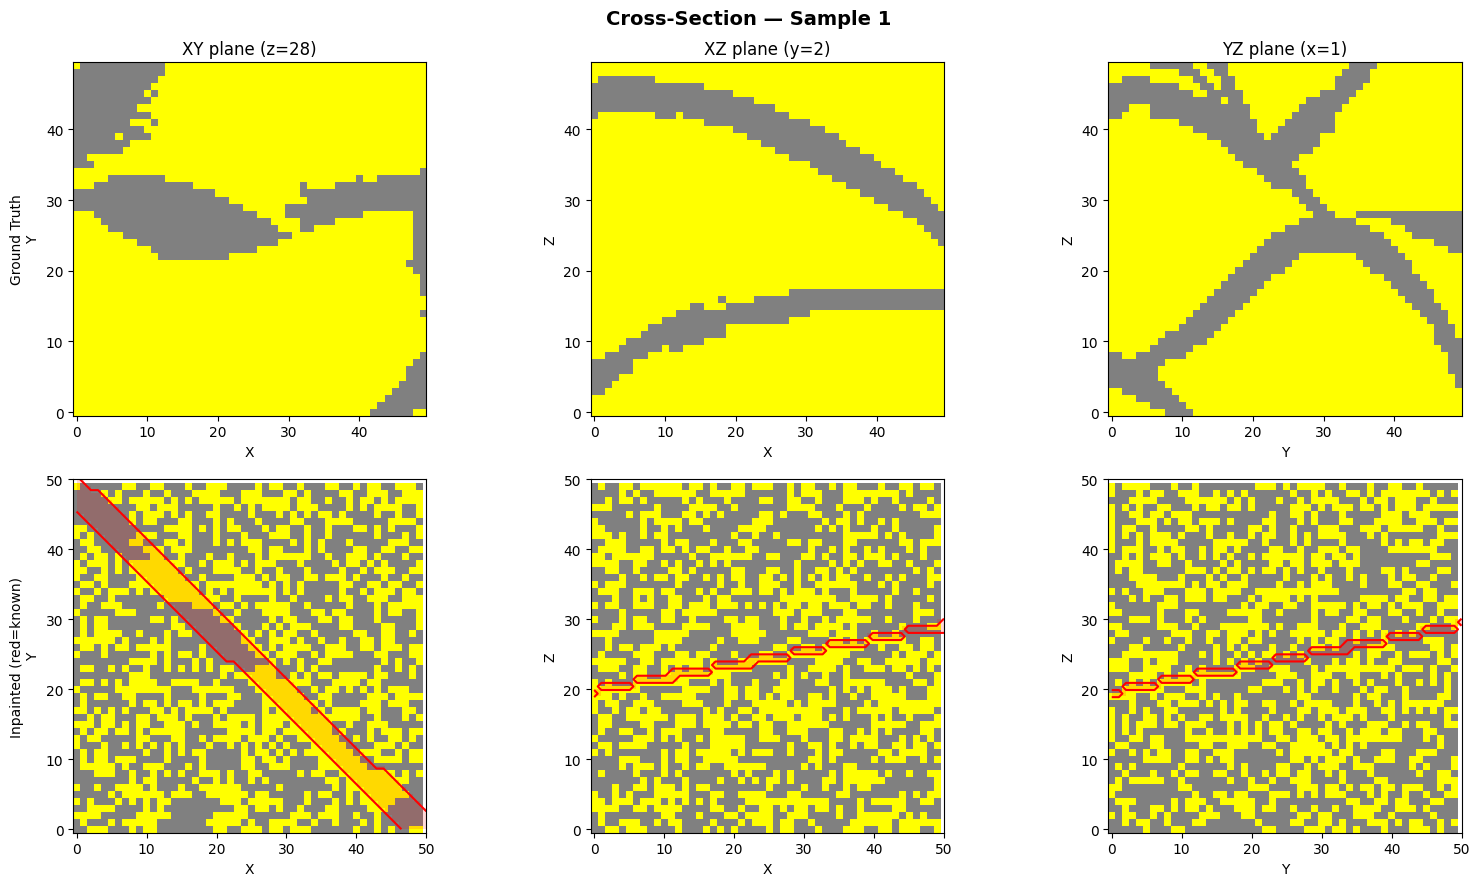

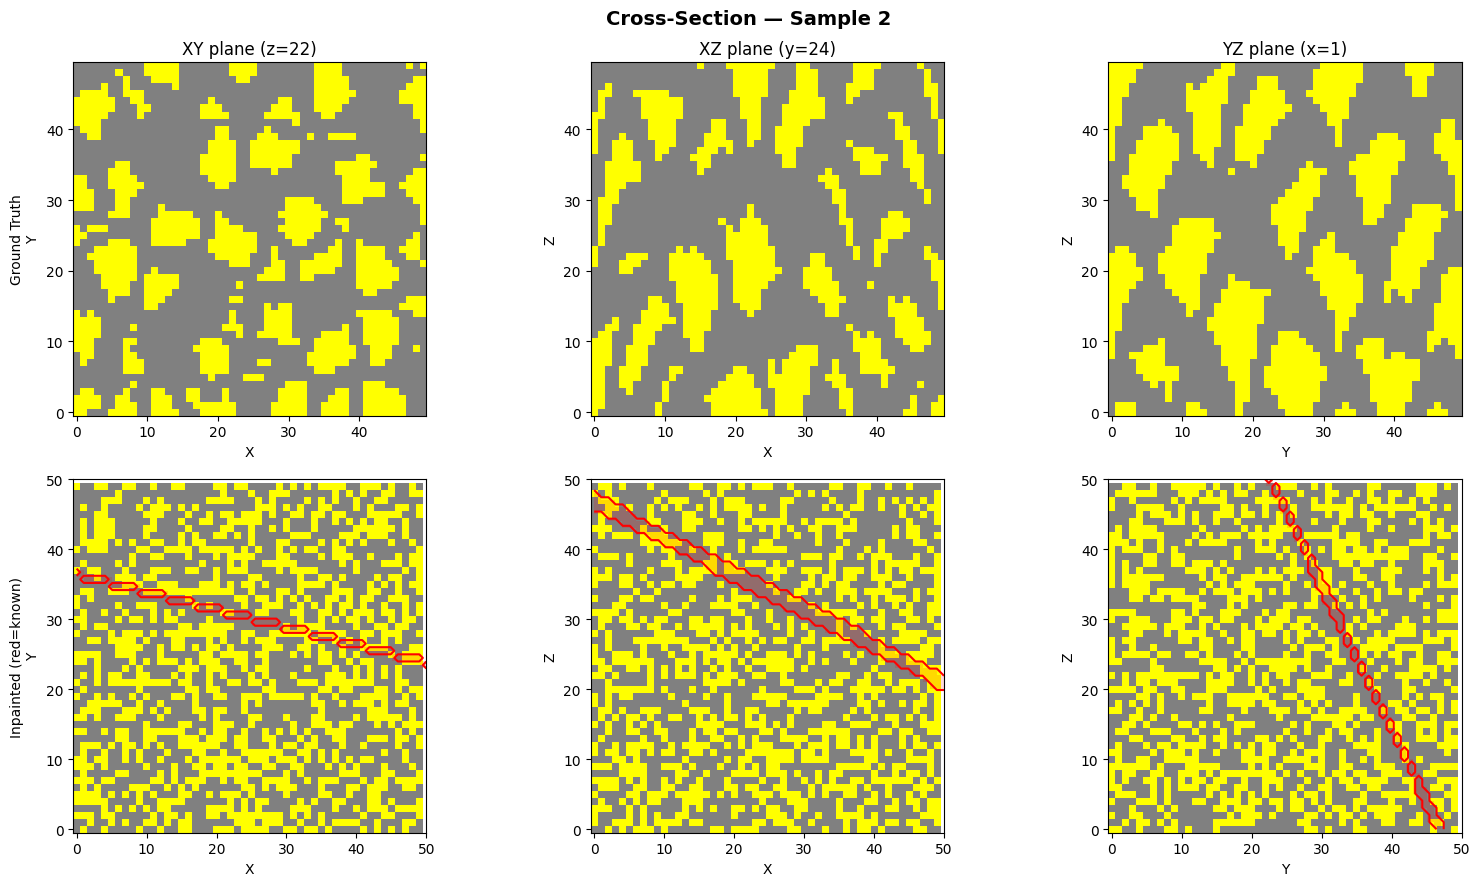

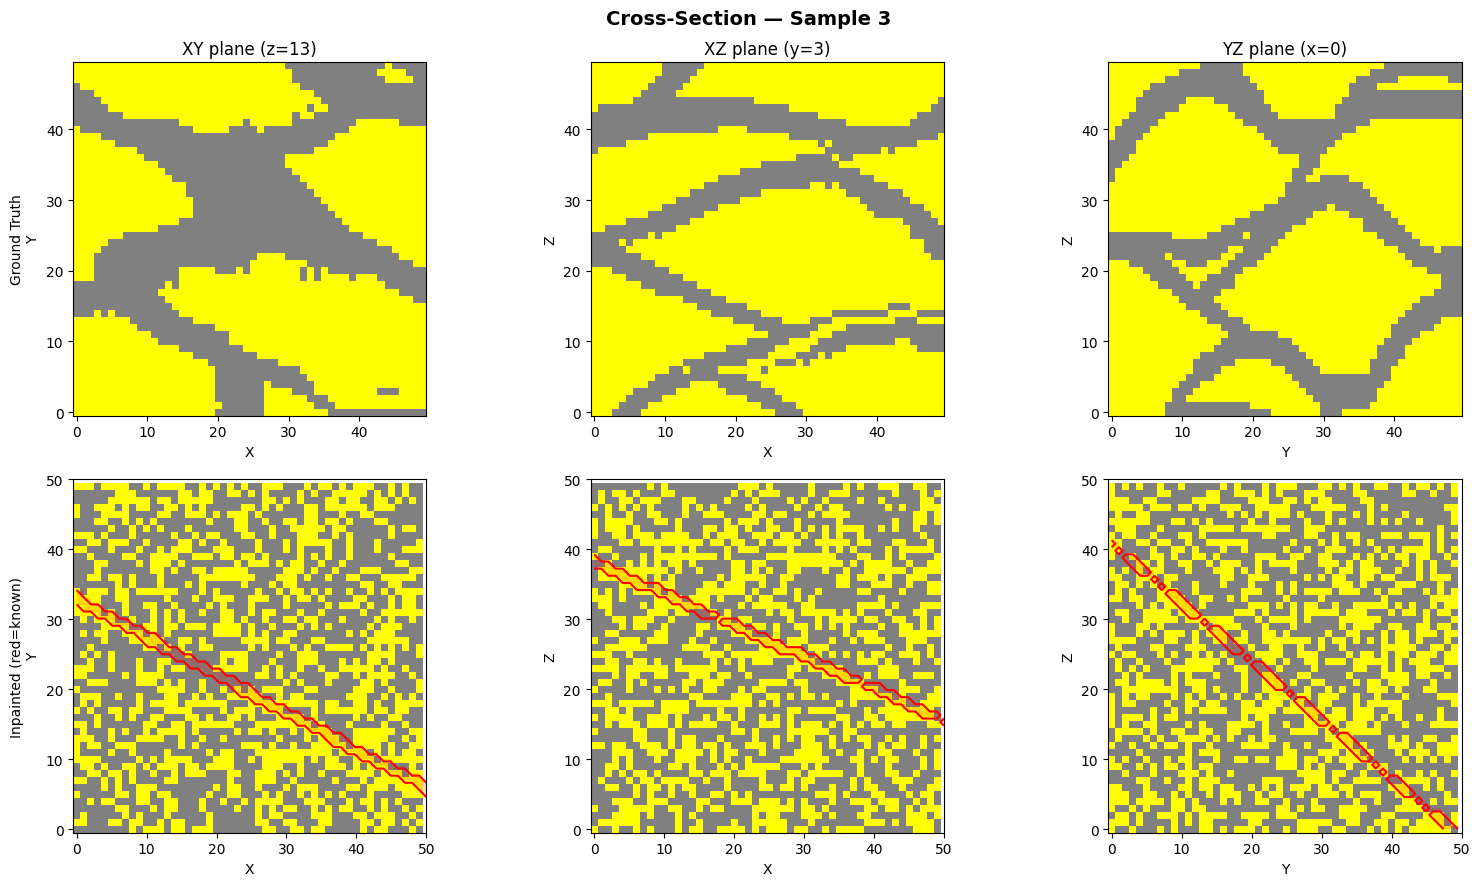

In [6]:
for i in range(n_samples):
    plot_inpaint_comparison(
        gt[i, 0], results['cross_section'][i, 0], masks['cross_section'][i, 0],
        f'Cross-Section — Sample {i}'
    )

## Combinations
Wells + boundaries, and all three mask types combined.

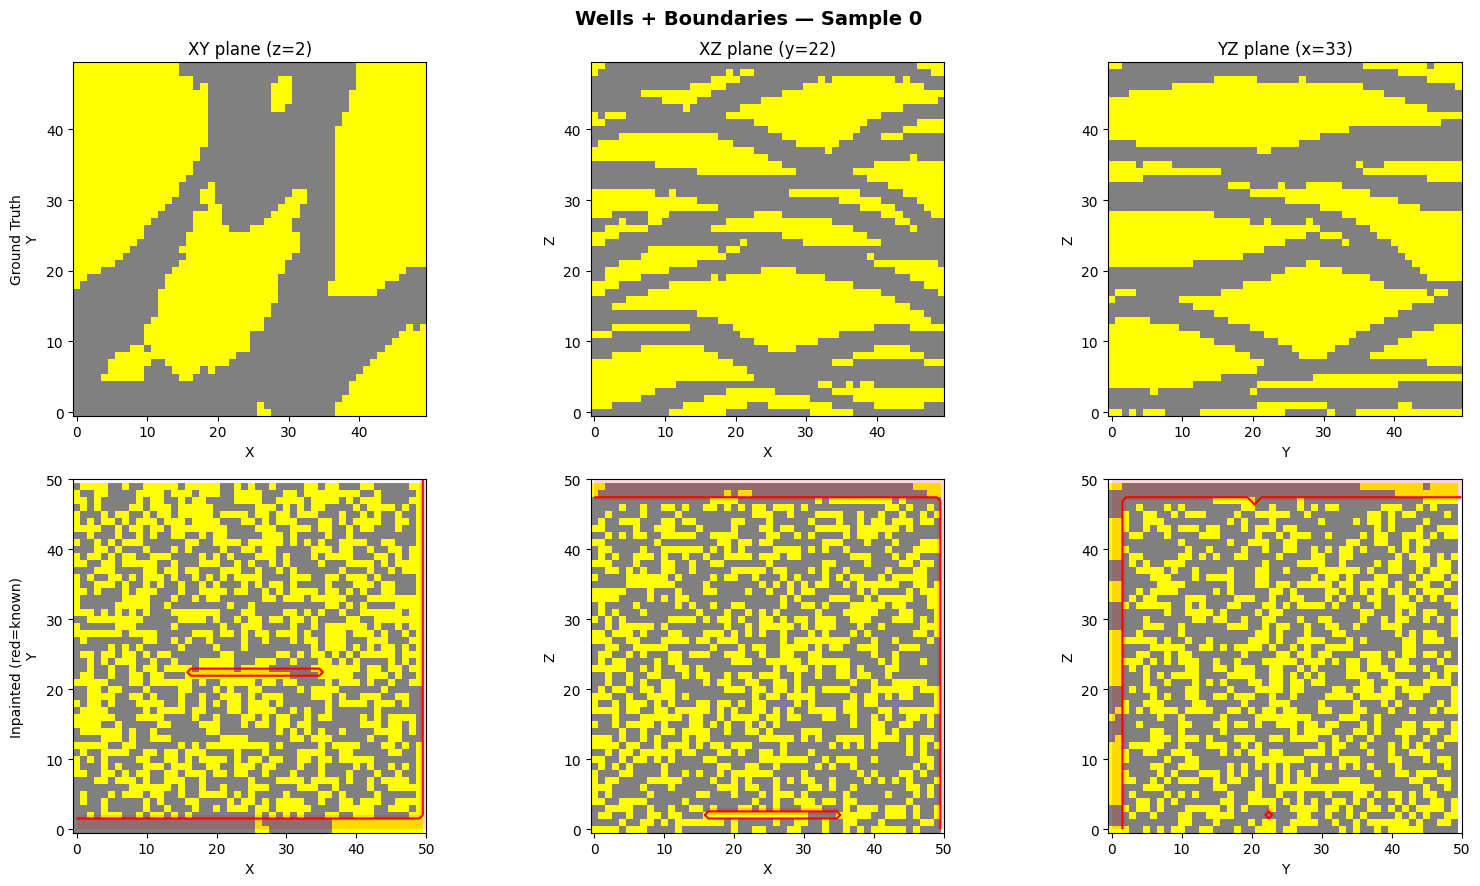

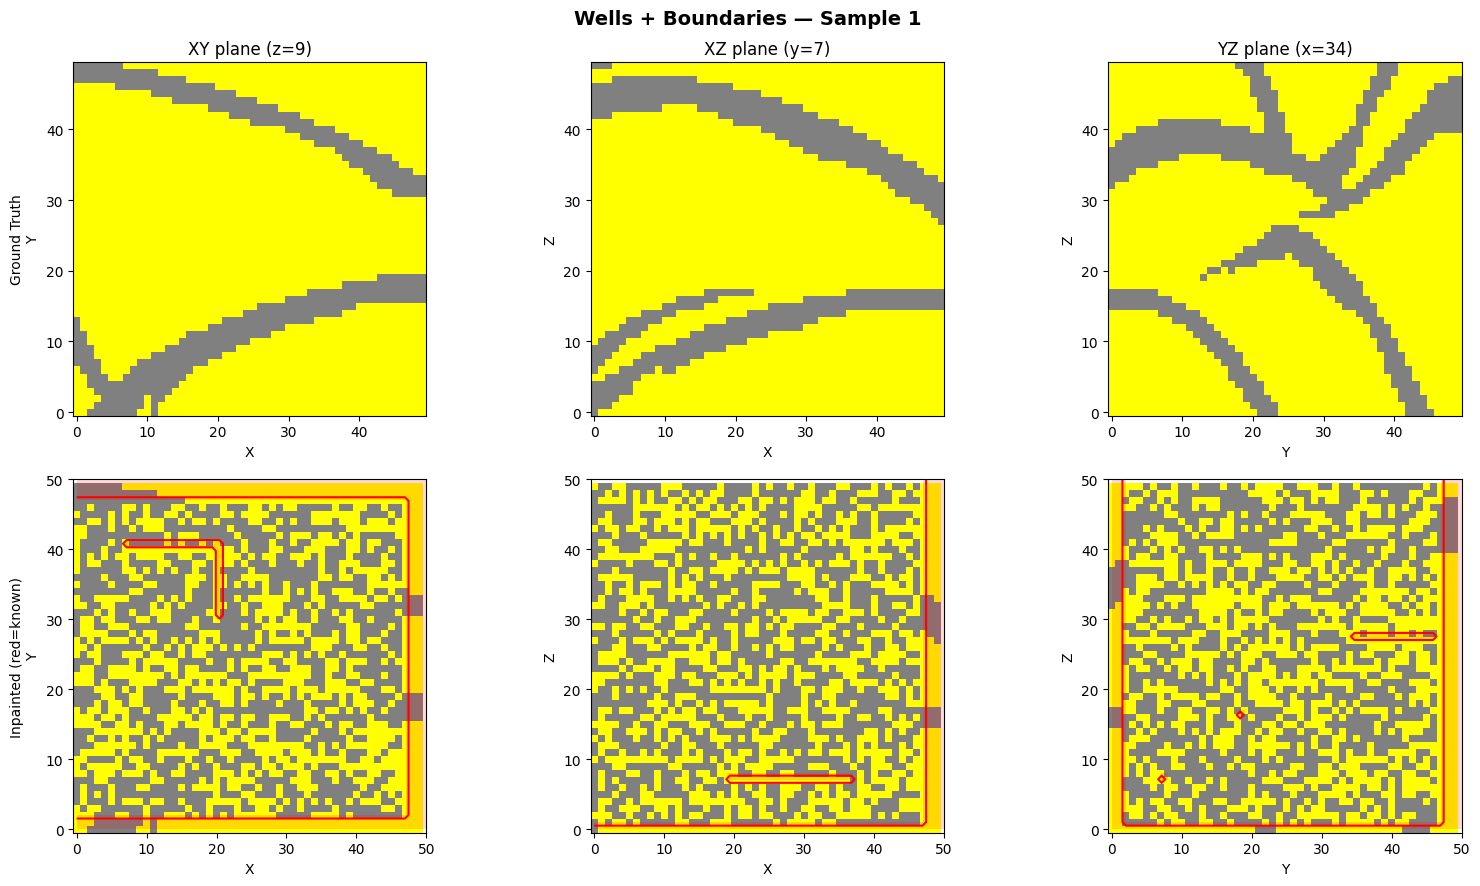

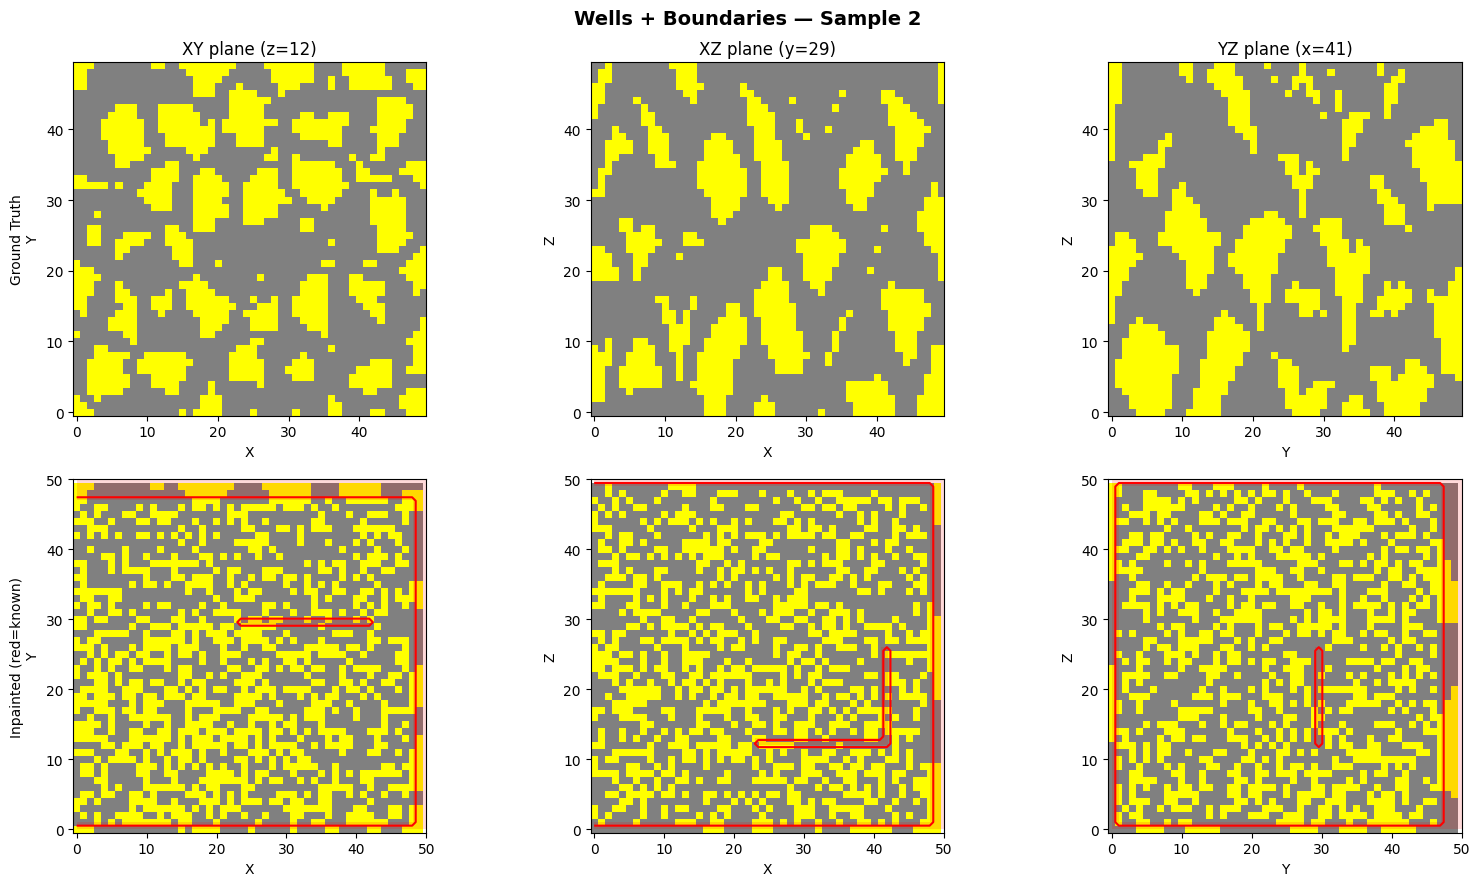

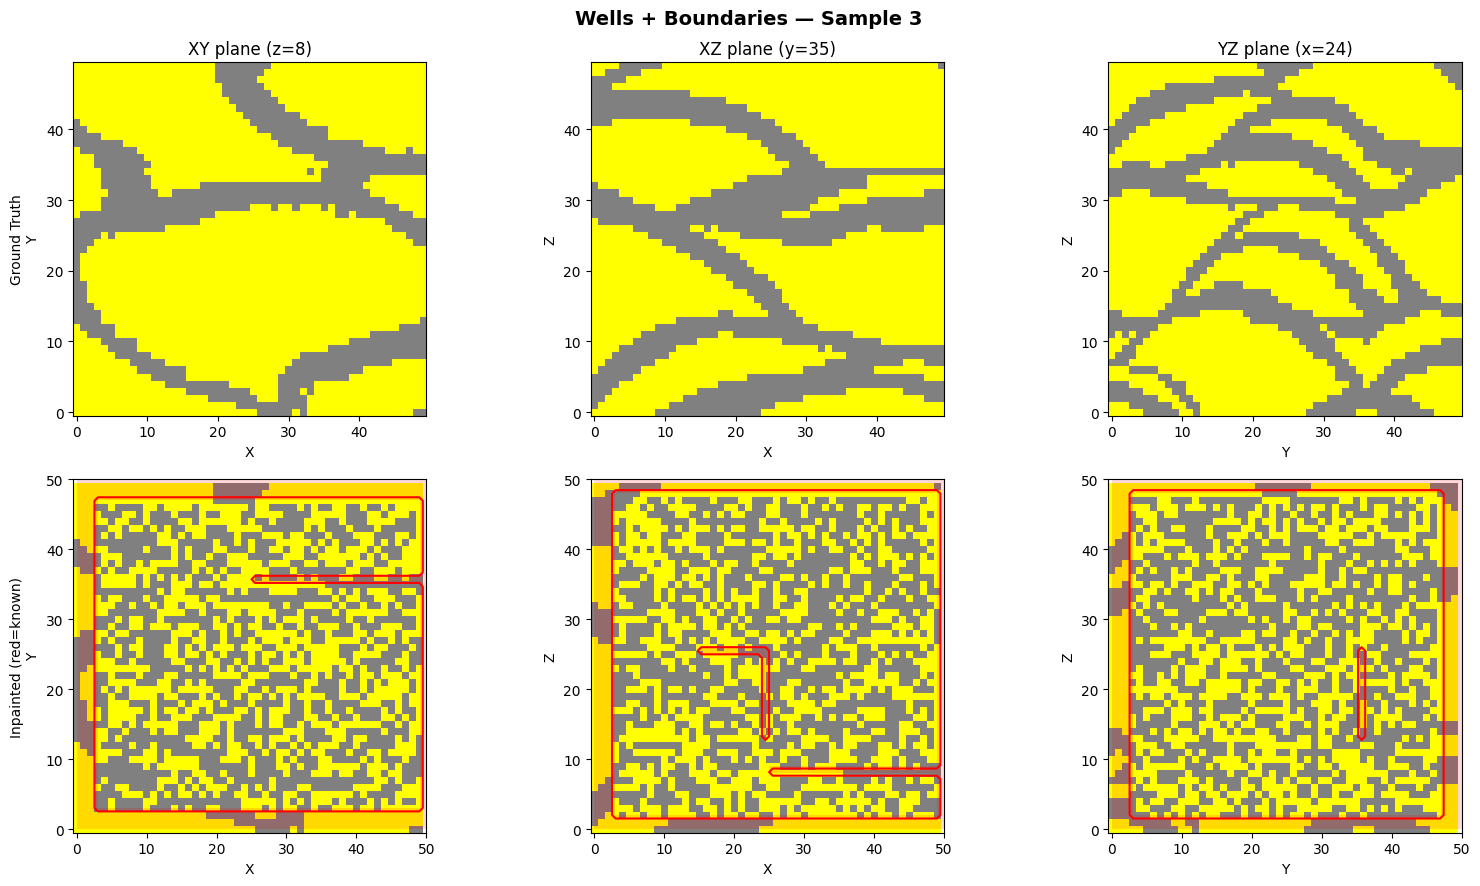

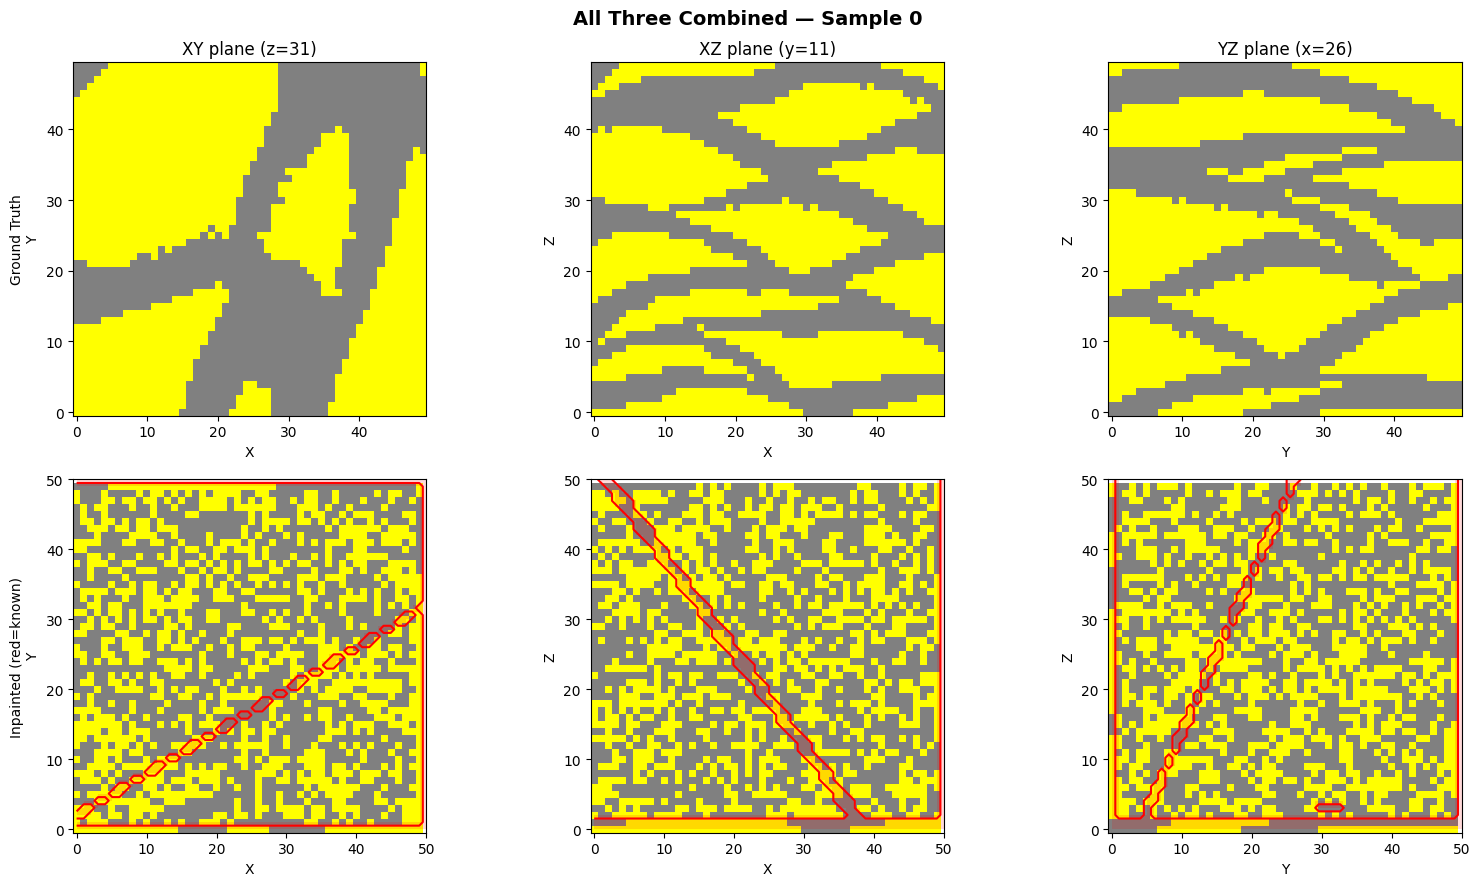

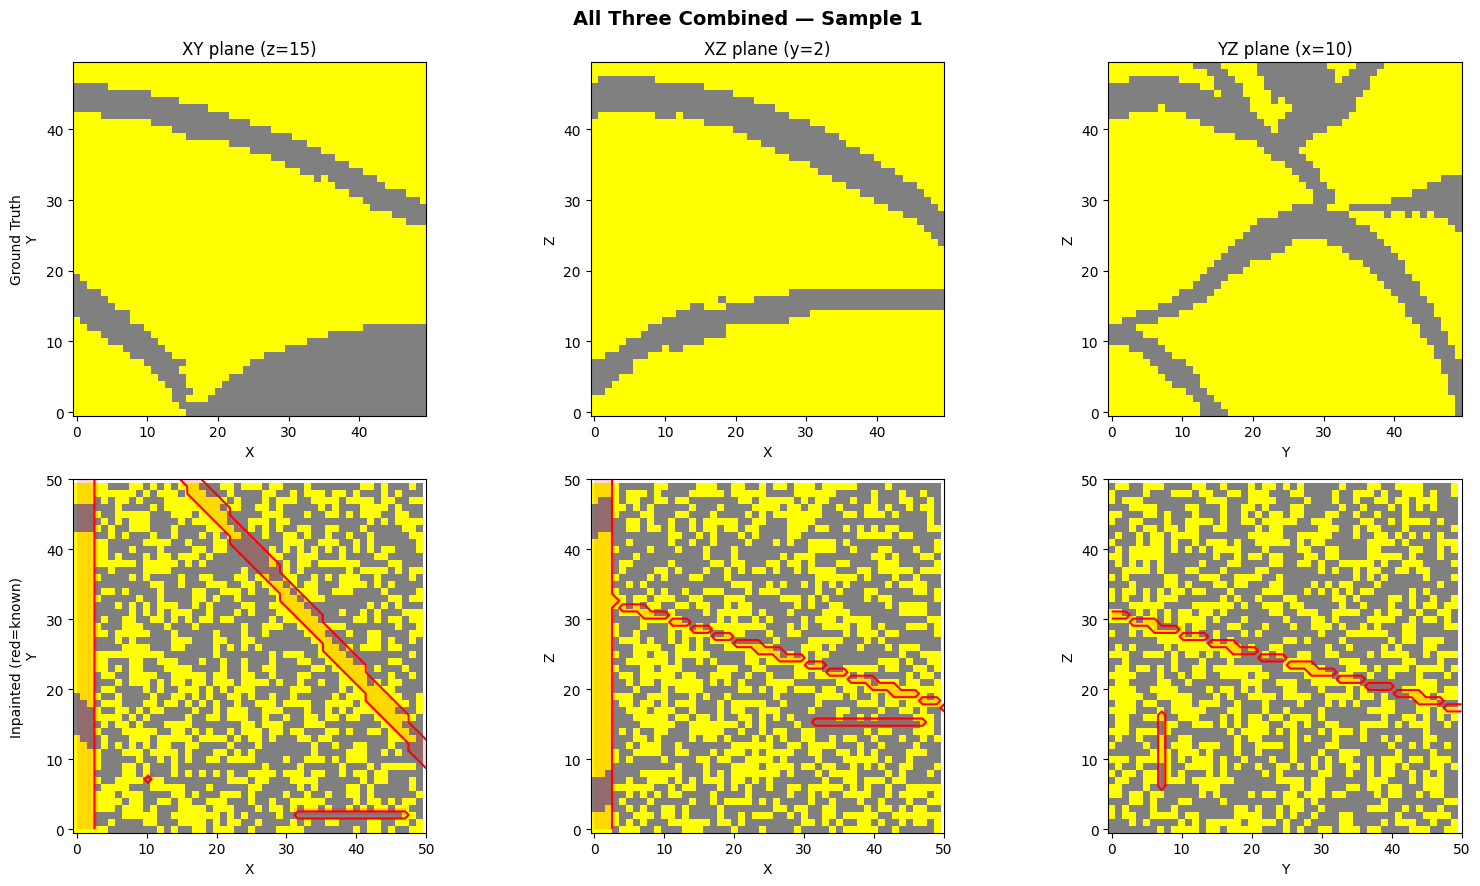

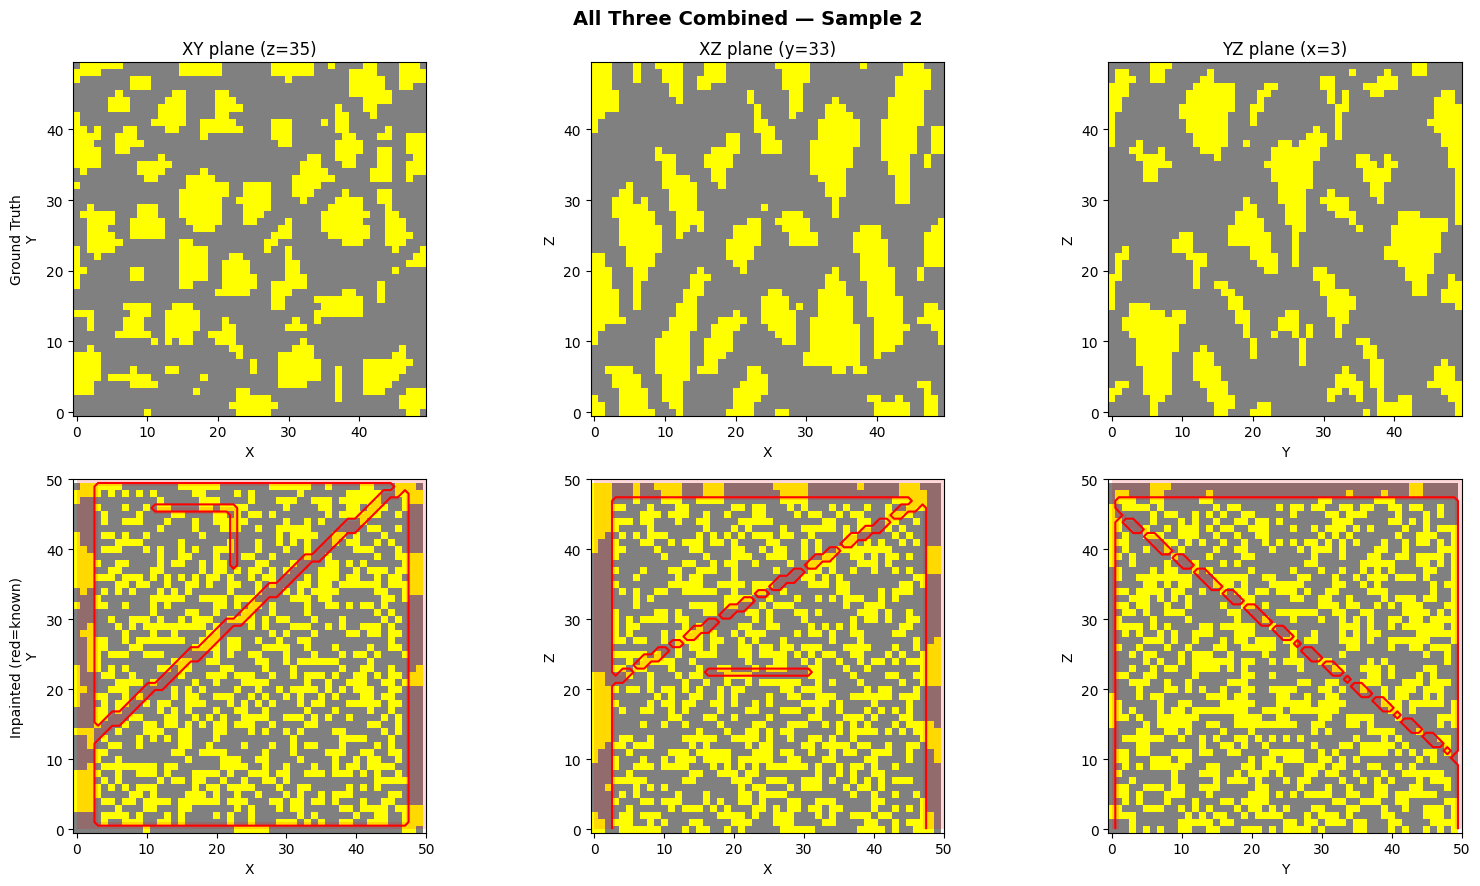

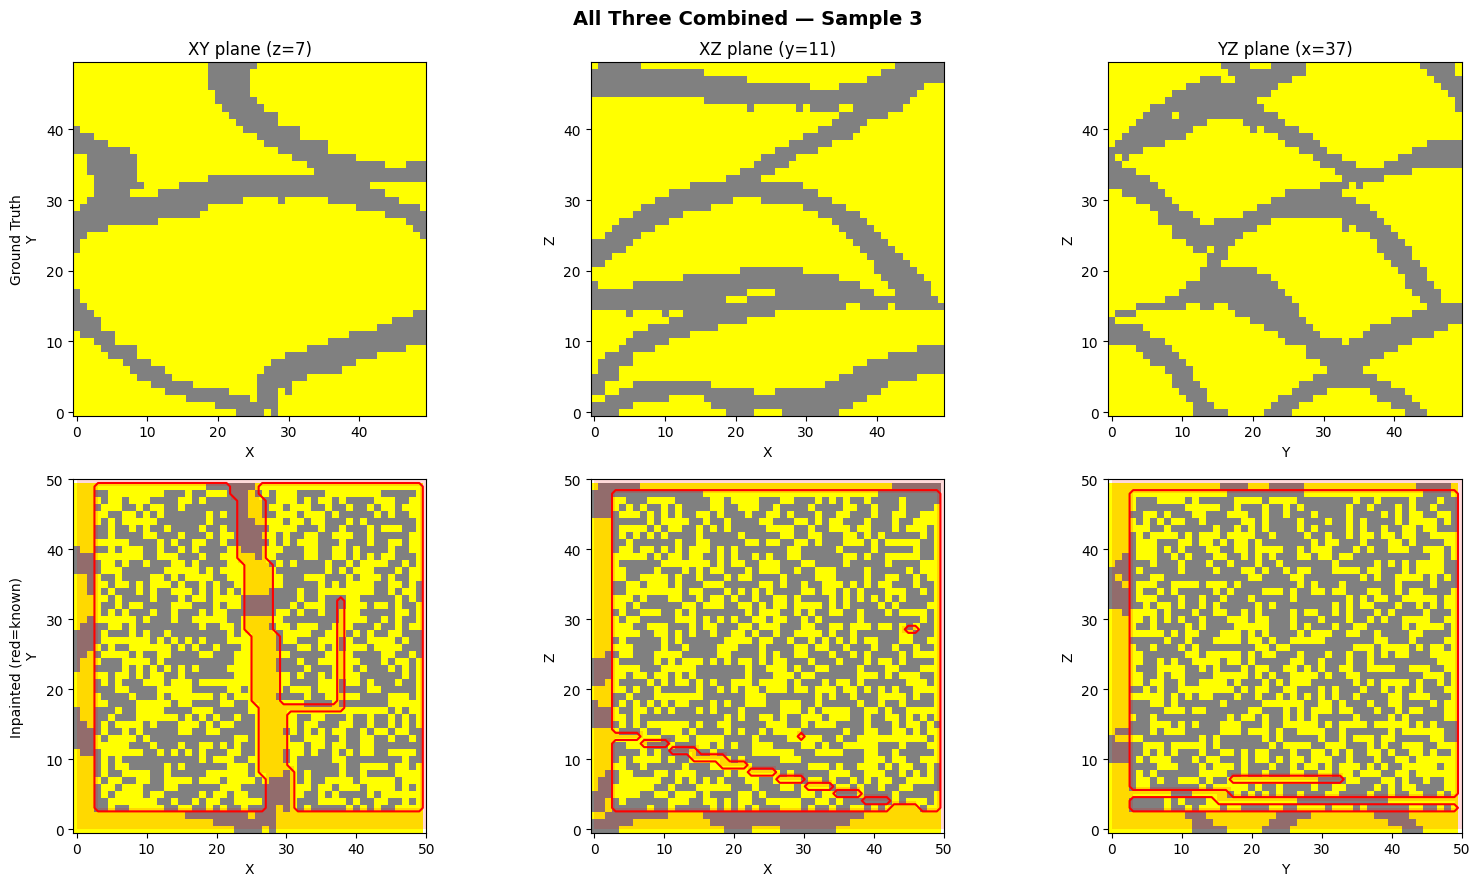

In [7]:
for i in range(n_samples):
    plot_inpaint_comparison(
        gt[i, 0], results['combo_wells_bounds'][i, 0], masks['combo_wells_bounds'][i, 0],
        f'Wells + Boundaries — Sample {i}'
    )

for i in range(n_samples):
    plot_inpaint_comparison(
        gt[i, 0], results['combo_all'][i, 0], masks['combo_all'][i, 0],
        f'All Three Combined — Sample {i}'
    )

## Summary Statistics
Known-region match rate and NTG comparison per mask type.

In [8]:
print(f"{'Mask Type':<25} {'Known %':>8} {'Match Rate':>11} {'GT NTG':>8} {'Result NTG':>11}")
print("-" * 68)
for name in mask_names:
    m = masks[name]
    r = results[name]
    known_frac = m.mean()
    mask_bool = m > 0.5
    match = (gt[mask_bool] == r[mask_bool]).mean() if mask_bool.any() else 1.0
    gt_ntg = gt.mean()
    res_ntg = r.mean()
    print(f"{name:<25} {known_frac:>7.1%} {match:>10.1%} {gt_ntg:>8.3f} {res_ntg:>11.3f}")

Mask Type                  Known %  Match Rate   GT NTG  Result NTG
--------------------------------------------------------------------
wells                        0.0%     100.0%    0.569       0.441
boundaries                  12.9%     100.0%    0.569       0.463
cross_section                2.1%     100.0%    0.569       0.441
combo_wells_bounds          17.4%     100.0%    0.569       0.472
combo_all                   16.9%     100.0%    0.569       0.461
